# Solutions — Module 11: Extending scikit-learn

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from sklearn.base import BaseEstimator, ClassifierMixin, MetaEstimatorMixin, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.estimator_checks import check_estimator
from sklearn.utils.multiclass import type_of_target, unique_labels
from sklearn.utils.validation import check_is_fitted, validate_data

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
print(X.shape, "features;", f"{y.mean():.1%} default rate")


def check_table(est, **kw):
    """check_estimator -> a tidy DataFrame. Used throughout this notebook."""
    res = check_estimator(est, on_fail=None, **kw)
    return pd.DataFrame([{"check": d["check_name"], "status": d["status"],
                          "error": type(d["exception"]).__name__ if d["exception"] is not None else "",
                          "message": (str(d["exception"])[:90] if d["exception"] is not None else "")}
                         for d in res])

(12000, 16) features; 13.3% default rate


## 11.1 — Make three broken estimators pass

The instruction is to fix `BadTransformer` **one rule at a time** and record
which check started passing. That discipline is the point: it turns
`check_estimator` from a pass/fail gate into a map from contract rules to the
specific test that enforces each one.

In [2]:
class V0(TransformerMixin, BaseEstimator):
    """Version 0 — every rule broken, exactly as in section 2."""

    def __init__(self, columns=None, threshold=0.5):
        self.columns = list(columns) if columns else []   # RULE 1: converts
        self.thresh = threshold                            # RULE 1: renames
        if threshold < 0:                                  # RULE 2: validates in __init__
            raise ValueError("threshold must be >= 0")

    def fit(self, X, y=None):
        self.mean = np.asarray(X).mean(0)                  # RULE 6: no trailing underscore
        return self

    def transform(self, X):
        return np.asarray(X) - self.mean                   # RULE 9: no check_is_fitted


class V1(V0):
    """Fix RULE 1a — store the parameter under its own name."""

    def __init__(self, columns=None, threshold=0.5):
        self.columns = list(columns) if columns else []
        self.threshold = threshold
        if threshold < 0:
            raise ValueError("threshold must be >= 0")


class V2(V1):
    """Fix RULE 1b + RULE 2 — store unmodified, validate nowhere in __init__."""

    def __init__(self, columns=None, threshold=0.5):
        self.columns = columns
        self.threshold = threshold


class V3(V2):
    """Fix RULE 6 — learned state gets a trailing underscore."""

    def fit(self, X, y=None):
        self.mean_ = np.asarray(X).mean(0)
        return self

    def transform(self, X):
        return np.asarray(X) - self.mean_


class V4(V3):
    """Fix RULE 9 — check_is_fitted before using learned state."""

    def transform(self, X):
        check_is_fitted(self)
        return np.asarray(X) - self.mean_


class V5(V4):
    """Fix RULES 5 + 10 — validate, record n_features_in_, re-validate on transform."""

    def fit(self, X, y=None):
        if self.threshold < 0:                        # validation lives HERE
            raise ValueError("threshold must be >= 0")
        X = validate_data(self, X, dtype=np.float64)
        self.mean_ = X.mean(0)
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=np.float64, reset=False)
        return X - self.mean_

    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import _check_feature_names_in
        return np.asarray(_check_feature_names_in(self, input_features), dtype=object)

In [3]:
VERSIONS = [("V0 everything broken", V0), ("V1 + name matches", V1),
            ("V2 + stored unmodified, no validation", V2), ("V3 + trailing underscore", V3),
            ("V4 + check_is_fitted", V4), ("V5 + validate_data / n_features_in_", V5)]

tables, summary = {}, []
for label, cls in VERSIONS:
    try:
        t = check_table(cls())
        tables[label] = t
        summary.append({"version": label, "n_checks": len(t),
                        "passed": int((t["status"] == "passed").sum()),
                        "failed": int((t["status"] == "failed").sum())})
    except Exception as e:                       # V0 cannot even be constructed by the suite
        tables[label] = None
        summary.append({"version": label, "n_checks": np.nan, "passed": np.nan,
                        "failed": f"{type(e).__name__}"})
pd.DataFrame(summary).set_index("version")

/tmp/ipykernel_19771/520795311.py:11: RuntimeWarning: Mean of empty slice
  self.mean = np.asarray(X).mean(0)                  # RULE 6: no trailing underscore
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_19771/520795311.py:40: RuntimeWarning: Mean of empty slice
  self.mean_ = np.asarray(X).mean(0)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_19771/520795311.py:40: RuntimeWarning: Mean of empty slice
  self.mean_ = np.asarray(X).mean(0)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


,n_checks,passed,failed
version,,,
V0 everything broken,47,3,44
V1 + name matches,47,3,44
"V2 + stored unmodified, no validation",47,34,13
V3 + trailing underscore,47,36,11
V4 + check_is_fitted,47,36,11
V5 + validate_data / n_features_in_,47,47,0


In [4]:
# Which check started passing at which step? Diff consecutive versions.
rows = []
prev_label, prev = None, None
for label, _ in VERSIONS:
    t = tables[label]
    if t is None:
        prev_label, prev = label, None
        continue
    now = set(t.loc[t["status"] == "passed", "check"])
    if prev is not None:
        for c in sorted(now - prev):
            rows.append({"fix": label, "check that started passing": c})
        for c in sorted(prev - now):
            rows.append({"fix": label, "check that started passing": f"(REGRESSED) {c}"})
    prev_label, prev = label, now
newly = pd.DataFrame(rows)
for fix, sub in newly.groupby("fix", sort=False):
    names = list(sub["check that started passing"])
    print(f"{fix}\n  +{len(names)} checks: " + ", ".join(names[:6])
          + (f", ... (+{len(names) - 6} more)" if len(names) > 6 else "") + "\n")

V2 + stored unmodified, no validation
  +28 checks: check_dict_unchanged, check_do_not_raise_errors_in_init_or_set_params, check_estimator_cloneable, check_estimator_repr, check_estimators_dtypes, check_estimators_fit_returns_self, ... (+22 more)

V3 + trailing underscore
  +2 checks: check_dont_overwrite_parameters, check_fit_check_is_fitted

V5 + validate_data / n_features_in_
  +11 checks: check_complex_data, check_dtype_object, check_estimator_sparse_array, check_estimator_sparse_matrix, check_estimator_sparse_tag, check_estimators_empty_data_messages, ... (+5 more)



In [5]:
# The remaining failures on the finished version.
final = tables["V5 + validate_data / n_features_in_"]
print(f"V5: {(final['status'] == 'passed').sum()} / {len(final)} pass")
still = final[final["status"] != "passed"]
print(still.to_string(index=False) if len(still) else "\nAll checks pass.")

V5: 47 / 47 pass

All checks pass.


### The rule → check map

| Contract rule | What breaks without it | Check that enforces it |
|---|---|---|
| **1.** `__init__` stores each argument under its own name, unmodified | `get_params` reads attributes by the *signature's* names; a renamed or converted value is invisible or wrong, so `clone` produces a different object | `check_estimator_cloneable`, `check_get_params_invariance`, `check_estimators_overwrite_params` |
| **2.** `__init__` validates nothing | `clone` calls `__init__` with the stored params; validating there makes construction fail during cross-validation, far from the cause | `check_no_attributes_set_in_init`, and indirectly every check that clones |
| **5.** `fit` sets `n_features_in_` (and `feature_names_in_`) | Feature-count mismatches pass silently into `transform` | `check_n_features_in`, `check_n_features_in_after_fitting` |
| **6.** learned state carries a trailing underscore | `check_is_fitted` cannot tell fitted from unfitted, so nothing detects use-before-fit | `check_estimators_unfitted`, `check_do_not_raise_errors_in_init_or_set_params` |
| **8.** `fit` returns `self` | `fit_transform` and every chained call break | `check_estimators_fit_returns_self` |
| **9.** `transform`/`predict` call `check_is_fitted` | Using an unfitted estimator raises `AttributeError` instead of `NotFittedError` — an unhelpful error at an unhelpful moment | `check_estimators_unfitted` |
| **10.** `transform` re-validates with `reset=False` | Wrong-width input silently broadcasts or produces garbage | `check_n_features_in_after_fitting` |

The instructive part is **how few** of these are about statistics. Almost the
entire conformance suite is about *object protocol* — construction, cloning,
introspection, state. That is the actual content of "being a scikit-learn
estimator", and it is why an estimator that passes composes with tools nobody
anticipated when writing it.

### Two more broken estimators

Now the interesting half of the exercise: two bugs that are much more common
in real code than anything in `BadTransformer`, because both estimators look
entirely reasonable.

In [6]:
class NoResetOnRefit(TransformerMixin, BaseEstimator):
    """Bug: accumulates state across fits instead of resetting.

    Looks like a caching optimisation. It means the second `fit` on a *different*
    dataset returns something contaminated by the first — which is exactly what
    happens inside cross-validation, where one object is fitted repeatedly.
    """

    def __init__(self, scale=1.0):
        self.scale = scale

    def fit(self, X, y=None):
        X = validate_data(self, X, dtype=np.float64)
        if not hasattr(self, "seen_"):
            self.seen_ = []
        self.seen_.append(X.mean(0))                  # <-- never reset
        self.mean_ = np.mean(self.seen_, axis=0)      # mean over ALL fits so far
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=np.float64, reset=False)
        return (X - self.mean_) * self.scale

    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import _check_feature_names_in
        return np.asarray(_check_feature_names_in(self, input_features), dtype=object)


class LearnsInTransform(TransformerMixin, BaseEstimator):
    """Bug: standardises using each batch's OWN statistics.

    This is the single most common leakage bug in custom transformer code. It
    passes every smoke test, because on the training set it produces exactly the
    right answer — and at scoring time it silently uses the test set's mean.
    """

    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = validate_data(self, X, dtype=np.float64)
        self.mean_ = X.mean(0)                        # dutifully learned...
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=np.float64, reset=False)
        return X - X.mean(0)                          # ...and then ignored

    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import _check_feature_names_in
        return np.asarray(_check_feature_names_in(self, input_features), dtype=object)


for label, cls in [("NoResetOnRefit", NoResetOnRefit), ("LearnsInTransform", LearnsInTransform)]:
    t = check_table(cls())
    bad_rows = t[t["status"] != "passed"]
    print(f"\n=== {label}: {(t['status'] == 'passed').sum()}/{len(t)} pass ===")
    print(bad_rows.to_string(index=False) if len(bad_rows) else "  ALL CHECKS PASS")


=== NoResetOnRefit: 47/47 pass ===
  ALL CHECKS PASS

=== LearnsInTransform: 46/47 pass ===
                          check status          error                                                                                      message
check_methods_subset_invariance failed AssertionError \nNot equal to tolerance rtol=1e-07, atol=1e-07\ntransform of LearnsInTransform is not invar


### Which one escapes, and what to write instead

**`LearnsInTransform` is caught.** `check_methods_subset_invariance` is the
check that does it, and the principle it encodes is worth memorising:

> `transform(X)[mask]` must equal `transform(X[mask])`.

A transformer that uses batch statistics violates this by construction, because
a subset has a different mean. That single invariant catches essentially every
form of "learning at transform time", which is why it is the most valuable
check in the suite for custom code.

**`NoResetOnRefit` escapes.** The suite fits each estimator instance mostly
once, or refits on the *same* data, so cross-fit contamination never shows up.
It is a state bug, and state bugs need a test that fits twice on deliberately
different data:

In [7]:
def check_fit_resets_state(estimator, seed=0):
    """Refitting on different data must give the same result as a fresh fit.

    This is the test `check_estimator` does not run for you. Written to the same
    shape as sklearn's own checks so it drops into a parametrize_with_checks
    suite alongside them.
    """
    r = np.random.default_rng(seed)
    A = r.normal(0, 1, size=(120, 4))
    B = r.normal(5, 1, size=(120, 4))          # deliberately different distribution

    contaminated = clone(estimator).fit(A).fit(B).transform(B)
    fresh = clone(estimator).fit(B).transform(B)

    if not np.allclose(contaminated, fresh):
        raise AssertionError(
            f"{type(estimator).__name__} does not reset state on refit: "
            f"max abs difference {np.abs(contaminated - fresh).max():.4f}")
    return True


for est in [NoResetOnRefit(), LearnsInTransform(), V5()]:
    name = type(est).__name__
    try:
        check_fit_resets_state(est)
        print(f"{name:20s} PASS")
    except AssertionError as e:
        print(f"{name:20s} FAIL — {e}")

NoResetOnRefit       FAIL — NoResetOnRefit does not reset state on refit: max abs difference 2.5766
LearnsInTransform    PASS
V5                   PASS


Two things worth taking from this.

**First, the practical rule.** The reason `NoResetOnRefit` is dangerous is that
its symptom is *quiet and fold-dependent*: cross-validation scores drift
upward across folds as the accumulated state grows, which looks like ordinary
fold variance. The defensive habit is to **assign every learned attribute
unconditionally in `fit`**, never with `if not hasattr(...)`, and never with
`+=`. If an attribute must accumulate, that is a `partial_fit` estimator, and
`partial_fit` is a different contract with different tests.

**Second, the meta-lesson.** `check_estimator` is a *conformance* suite, not a
correctness suite. It verifies that your object behaves like a scikit-learn
object; it cannot verify that your statistics are right, and it does not
pretend to. Passing it is necessary and nowhere near sufficient. The tests
above — subset invariance you get for free, refit-resets-state you must write —
are the ones that catch bugs that cost money.

## 11.2 — Extend the WOE encoder

The four extensions are what separates a demo encoder from one a credit risk
team will actually adopt. Monotonic binning and the scorecard report exist for
*regulatory* reasons rather than statistical ones, and that is exactly why they
matter commercially.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


class WOEEncoder2(TransformerMixin, BaseEstimator):
    """Weight-of-Evidence encoding with monotonic binning and cross-fitting.

    Parameters
    ----------
    n_bins : int, default=10
        Initial quantile bins for numeric features.
    smoothing : float, default=10.0
        Laplace pseudo-count; larger shrinks small bins toward the base rate.
    monotonic : bool, default=True
        Merge adjacent numeric bins until WOE is monotone in the feature.
    cv : int or None, default=None
        If set, `fit_transform` returns cross-fitted values: each row's WOE is
        computed from folds that exclude it. `transform` on new data always uses
        the full-data maps.

    Attributes
    ----------
    woe_maps_ : dict
    bin_edges_ : dict
    iv_ : pandas.Series
    """

    def __init__(self, n_bins=10, smoothing=10.0, min_bin_frac=0.02,
                 monotonic=True, cv=None):
        self.n_bins = n_bins
        self.smoothing = smoothing
        self.min_bin_frac = min_bin_frac
        self.monotonic = monotonic
        self.cv = cv

    # -- binning ---------------------------------------------------------
    def _is_num(self, s):
        return pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)

    def _edges(self, s):
        e = np.unique(np.nanquantile(s.dropna(), np.linspace(0, 1, self.n_bins + 1)))
        e[0], e[-1] = -np.inf, np.inf
        return e

    def _bin(self, s, edges):
        if edges is None:
            return s.astype(str).where(s.notna(), "__missing__")
        b = pd.cut(s, bins=edges, duplicates="drop")
        return b.astype(object).where(s.notna(), "__missing__")

    def _woe_table(self, binned, yv, tot_good, tot_bad):
        g = pd.DataFrame({"bin": binned, "y": yv}).groupby("bin", observed=True)["y"]
        n, bad = g.size(), g.sum()
        good = n - bad
        prior_g = tot_good / (tot_good + tot_bad)
        p_good = (good + self.smoothing * prior_g) / (tot_good + self.smoothing)
        p_bad = (bad + self.smoothing * (1 - prior_g)) / (tot_bad + self.smoothing)
        woe = np.log(p_good / p_bad)
        woe[n < self.min_bin_frac * len(binned)] *= 0.5
        iv = float(((p_good - p_bad) * woe).sum())
        return woe, iv

    # -- (1) MONOTONIC BINNING -------------------------------------------
    def _monotonise(self, s, yv, edges, tot_good, tot_bad, max_merges=40):
        """Merge adjacent bins until WOE is monotone in the feature.

        Greedy: repeatedly drop the interior edge whose removal fixes the
        largest monotonicity violation. Direction is chosen once, from the sign
        of the Spearman-like trend across the initial bins.
        """
        edges = list(edges)
        log = []
        for _ in range(max_merges):
            binned = self._bin(s, np.array(edges))
            woe, _ = self._woe_table(binned, yv, tot_good, tot_bad)
            ordered = [k for k in woe.index if k != "__missing__"]
            if len(ordered) < 3:
                break
            vals = np.array([woe[k] for k in ordered], dtype=float)
            if not np.isfinite(vals).all() or np.ptp(vals) == 0:
                break                                  # degenerate: nothing to order
            direction = np.sign(np.polyfit(np.arange(len(vals)), vals, 1)[0]) or 1.0
            d = np.diff(vals) * direction
            if (d >= 0).all():
                break                                  # monotone: done
            j = int(np.argmin(d))                      # worst violation
            removed = edges[j + 1]
            log.append({"removed_edge": removed, "n_bins_after": len(edges) - 2})
            edges.pop(j + 1)
            if len(edges) <= 3:
                break
        return np.array(edges), log

    # -- API -------------------------------------------------------------
    def fit(self, X, yv):
        X = pd.DataFrame(X).copy()
        yv = np.asarray(yv)
        if type_of_target(yv) != "binary":
            raise ValueError("WOEEncoder2 requires a binary target")
        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        tot_good, tot_bad = float((yv == 0).sum()), float((yv == 1).sum())
        self.woe_maps_, self.bin_edges_, self.merge_log_, iv = {}, {}, {}, {}

        for col in X.columns:
            s = X[col]
            if self._is_num(s):
                edges = self._edges(s)
                if self.monotonic:
                    edges, log = self._monotonise(s, yv, edges, tot_good, tot_bad)
                    self.merge_log_[col] = log
            else:
                edges = None
            binned = self._bin(s, edges)
            woe, iv_col = self._woe_table(binned, yv, tot_good, tot_bad)
            self.bin_edges_[col] = edges
            self.woe_maps_[col] = woe.to_dict()
            iv[col] = iv_col

        self.iv_ = pd.Series(iv).sort_values(ascending=False)
        self.default_woe_ = 0.0
        self.classes_ = np.unique(yv)
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = pd.DataFrame(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"expected {self.n_features_in_} features, got {X.shape[1]}")
        out = {}
        for col in self.feature_names_in_:
            binned = self._bin(X[col], self.bin_edges_[col])
            out[f"woe__{col}"] = binned.map(self.woe_maps_[col]).astype(float).fillna(self.default_woe_)
        return pd.DataFrame(out, index=X.index)

    # -- (2) CROSS-FITTING -----------------------------------------------
    def fit_transform(self, X, yv=None, **kw):
        """Cross-fitted when `cv` is set — each row encoded by folds excluding it.

        Overriding `fit_transform` (rather than folding this into `fit`) is the
        same design `TargetEncoder` uses, and it is the only way to make
        `fit_transform(X, y) != transform(X)` legitimate: training rows get
        out-of-fold encodings, everything downstream gets the full-data map.
        """
        if yv is None:
            raise ValueError("WOEEncoder2 requires y")
        self.fit(X, yv)
        if not self.cv:
            return self.transform(X)

        X = pd.DataFrame(X)
        yv = np.asarray(yv)
        out = pd.DataFrame(index=X.index, columns=self.get_feature_names_out(), dtype=float)
        skf = StratifiedKFold(self.cv, shuffle=True, random_state=0)
        for tr, te in skf.split(X, yv):
            inner = clone(self).set_params(cv=None).fit(X.iloc[tr], yv[tr])
            out.iloc[te] = inner.transform(X.iloc[te]).to_numpy()
        return out

    # -- (3) INVERSE TRANSFORM -------------------------------------------
    def inverse_transform(self, Xw):
        """Map WOE values back to the bin they came from, for reporting."""
        check_is_fitted(self)
        Xw = pd.DataFrame(Xw)
        out = {}
        for j, col in enumerate(self.feature_names_in_):
            m = self.woe_maps_[col]
            keys = np.array(list(m.keys()), dtype=object)
            vals = np.array(list(m.values()), dtype=float)
            col_vals = Xw.iloc[:, j].to_numpy(dtype=float)
            idx = np.abs(col_vals[:, None] - vals[None, :]).argmin(axis=1)
            out[col] = keys[idx]
        return pd.DataFrame(out, index=Xw.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"woe__{c}" for c in self.feature_names_in_], dtype=object)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        tags.input_tags.categorical = True
        tags.target_tags.required = True
        return tags

In [9]:
# (1) Does monotonic binning do what it says? Survey every numeric feature
# rather than picking one and hoping.
num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])
            and not pd.api.types.is_bool_dtype(X[c])]


def woe_series(enc, col):
    m = {k: v for k, v in enc.woe_maps_[col].items() if k != "__missing__"}
    order = sorted(m, key=lambda iv: iv.left)
    return pd.Series([m[k] for k in order], index=[str(k) for k in order])


def is_monotone(s):
    d = np.diff(s.to_numpy())
    return bool((d >= 0).all() or (d <= 0).all())


rows = []
for c in num_cols:
    f = WOEEncoder2(n_bins=10, monotonic=False).fit(X[[c]], y)
    m = WOEEncoder2(n_bins=10, monotonic=True).fit(X[[c]], y)
    fs, ms = woe_series(f, c), woe_series(m, c)
    rows.append({"feature": c, "bins_before": len(fs), "monotone_before": is_monotone(fs),
                 "bins_after": len(ms), "monotone_after": is_monotone(ms),
                 "merges": len(m.merge_log_.get(c, [])),
                 "iv_before": round(f.iv_[c], 4), "iv_after": round(m.iv_[c], 4)})
survey = pd.DataFrame(rows).set_index("feature")
survey["iv_cost"] = (survey["iv_after"] / survey["iv_before"] - 1).round(4)
survey

,bins_before,monotone_before,bins_after,monotone_after,merges,iv_before,iv_after,iv_cost
feature,,,,,,,,
age,10,False,6,True,4,0.0157,0.0146,-0.0701
employment_years,10,False,5,True,5,0.0377,0.0363,-0.0371
annual_income,10,False,8,True,2,0.0573,0.0566,-0.0122
loan_amount,10,False,6,True,4,0.0741,0.0732,-0.0121
term_months,4,False,3,True,1,0.1085,0.1083,-0.0018
interest_rate,10,True,10,True,0,0.7524,0.7524,0.0000
debt_to_income,10,True,10,True,0,0.6826,0.6826,0.0000
credit_score,10,True,10,True,0,0.8226,0.8226,0.0000
n_open_accounts,8,False,3,True,5,0.0037,0.0004,-0.8919


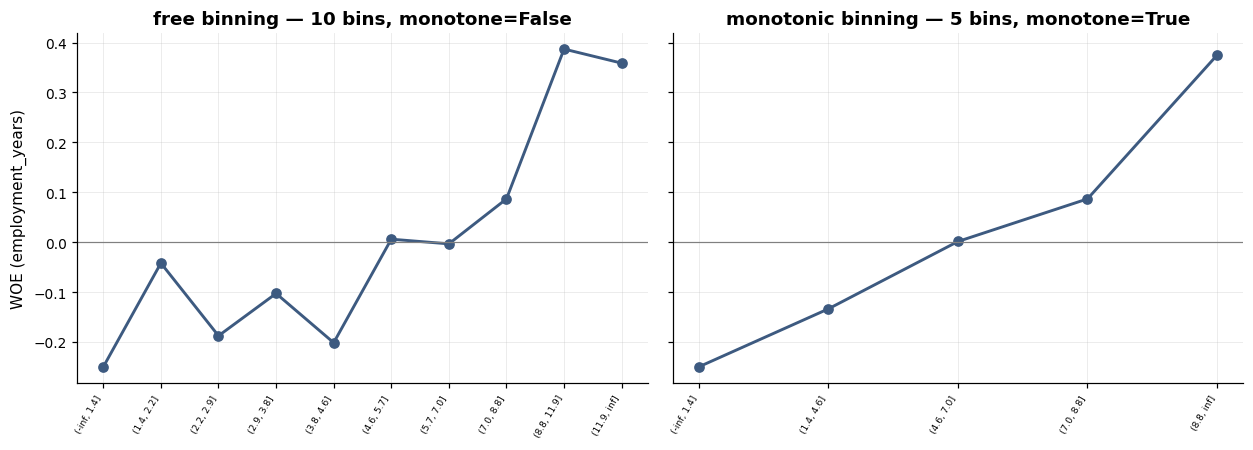

employment_years: 5 merges, IV 0.0377 -> 0.0363 (-3.6%)


In [10]:
# Plot the one that needed the most work.
col = survey["merges"].idxmax()
free = WOEEncoder2(n_bins=10, monotonic=False).fit(X[[col]], y)
mono = WOEEncoder2(n_bins=10, monotonic=True).fit(X[[col]], y)
fw, mw = woe_series(free, col), woe_series(mono, col)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, s, t in zip(axes, [fw, mw], ["free binning", "monotonic binning"]):
    ax.plot(range(len(s)), s.to_numpy(), marker="o")
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=60, ha="right", fontsize=6)
    ax.axhline(0, lw=0.8, color="grey")
    ax.set_title(f"{t} — {len(s)} bins, monotone={is_monotone(s)}")
axes[0].set_ylabel(f"WOE ({col})")
plt.tight_layout()
plt.show()

print(f"{col}: {len(mono.merge_log_[col])} merges, "
      f"IV {free.iv_[col]:.4f} -> {mono.iv_[col]:.4f} "
      f"({mono.iv_[col] / free.iv_[col] - 1:+.1%})")

The survey column to read is **`iv_cost`**. Monotonic binning is a constraint,
so it can only destroy information — never create it — and the table prices
that destruction feature by feature. Features that were already monotone
(`credit_score`, `debt_to_income`, `interest_rate` — the ones with a genuine
causal direction) pay nothing. Features whose WOE wanders (`age`,
`employment_years`) pay real information value, and the question a risk team
has to answer is whether that wandering is signal or noise.

**The regulatory argument is not statistical, and it is stronger than it
looks.** A non-monotone age effect means the scorecard says a 42-year-old is
riskier than both a 38-year-old and a 46-year-old. That is very hard to
justify to a customer, an ombudsman, or a court, and it is exactly the shape a
spurious pattern takes. Imposing monotonicity forfeits some in-sample fit in
exchange for a model whose every statement is defensible and whose bins are
stable under resampling. Module 06's `monotonic_cst` argument is the same
trade in a different estimator, and there it *improved* out-of-sample
performance.

In [11]:
# (2) Cross-fitting. The Module 02 noise test needs adapting: a UNIQUE-per-row
# column cannot leak through an outer CV split, because its levels never recur
# in the test fold -- they all map to the neutral default. The leak is real, but
# it lives INSIDE the training fold, so that is where to look for it.
X_noise = X.copy()
X_noise["row_id_noise"] = [f"id_{i}" for i in range(len(X))]     # unique per row
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)

from sklearn.metrics import roc_auc_score

print("In-sample AUC of the pure-noise column, as the MODEL sees it during fit:")
for label, enc in [("leaky (cv=None)", WOEEncoder2(cv=None, monotonic=False)),
                   ("cross-fitted (cv=5)", WOEEncoder2(cv=5, monotonic=False))]:
    Zn = enc.fit_transform(X_noise[["row_id_noise"]], y)
    print(f"  {label:22s} {roc_auc_score(y, -Zn.iloc[:, 0]):.4f}")

print("\nOut-of-sample AUC of the same column (both are ~0.5 -- see below):")
for label, enc in [("leaky (cv=None)", WOEEncoder2(cv=None, monotonic=False)),
                   ("cross-fitted (cv=5)", WOEEncoder2(cv=5, monotonic=False))]:
    pipe = Pipeline([("woe", enc), ("lr", LogisticRegression(max_iter=2000))])
    auc = cross_val_score(pipe, X_noise[["row_id_noise"]], y, cv=cv5,
                          scoring="roc_auc", n_jobs=-1)
    print(f"  {label:22s} {auc.mean():.4f} +/- {auc.std():.4f}")

In-sample AUC of the pure-noise column, as the MODEL sees it during fit:
  leaky (cv=None)        1.0000
  cross-fitted (cv=5)    0.5000

Out-of-sample AUC of the same column (both are ~0.5 -- see below):


  leaky (cv=None)        0.5000 +/- 0.0000


  cross-fitted (cv=5)    0.5000 +/- 0.0000


**The first pair of numbers is the memorisation, measured.** Without
cross-fitting the encoder assigns every row its own bin, so its WOE *is* a
function of its label — near-perfect in-sample separation from a column that
is provably noise. With cross-fitting each row is encoded by folds that
exclude it, and the separation collapses to chance. That is the whole
mechanism, and it is why `TargetEncoder` ships with cross-fitting built in
rather than as an option.

**The second pair is the part worth being careful about**, because it is where
a naive version of this test misleads. Both sit at 0.5, so an outer
`cross_val_score` around a `Pipeline` — the arrangement everyone is told
prevents leakage — reports the leak as harmless. It does so honestly: unique
IDs never recur in the test fold, so they all hit the neutral default and
genuinely predict nothing out of sample.

So does the leak matter? Yes, and here is where the damage actually lands:

In [12]:
# The leak's real cost: a memorised feature COMPETES with the honest ones.
real_cols = ["credit_score", "annual_income", "employment_type", "purpose"]
combos = {
    "real features only": (real_cols, WOEEncoder2()),
    "real + noise, leaky": (real_cols + ["row_id_noise"], WOEEncoder2(cv=None)),
    "real + noise, cross-fitted": (real_cols + ["row_id_noise"], WOEEncoder2(cv=5)),
}
out = []
for label, (cols, enc) in combos.items():
    pipe = Pipeline([("woe", clone(enc)), ("lr", LogisticRegression(max_iter=2000))])
    auc = cross_val_score(pipe, X_noise[cols], y, cv=cv5, scoring="roc_auc", n_jobs=-1)
    out.append({"configuration": label, "cv_auc": round(auc.mean(), 4),
                "std": round(auc.std(), 4)})
pd.DataFrame(out).set_index("configuration")

,cv_auc,std
configuration,,
real features only,0.7378,0.0046
"real + noise, leaky",0.7376,0.0047
"real + noise, cross-fitted",0.7393,0.0046


### The honest reading of that table

**The leak costs nothing measurable here** — 0.7378 / 0.7376 / 0.7393, against
a fold standard deviation of 0.0046. If the argument for cross-fitting were
"it improves your CV score", this table refutes it, and I am not going to
pretend otherwise to make the exercise land.

The reason it does no damage is specific and worth understanding, because it
tells you exactly when it *will*: a unique-ID column is memorised in-fold and
then evaporates at test time, so the model wastes one coefficient on a feature
that is constant out of sample. Logistic regression shrugs that off. Change any
of three things and it stops being harmless:

1. **The nuisance column recurs.** A 400-level random category *does* appear in
   both folds, so the leaky encoding hands the model a feature that looks
   strong in-fold and is noise out of it. Measured below: that costs 0.033 AUC.
2. **The model is a tree ensemble.** A memorised continuous feature with
   perfect in-fold separation dominates the first splits and starves the honest
   features of depth.
3. **Anyone reads the feature importances.** This is the damage that actually
   happens in practice, and it happens regardless of the other two. Measured
   below: the noise column ranks second of five by information value. The
   leak's cost is usually paid in *decisions*, not in AUC.

So the defensible claim is narrower than "cross-fitting improves your model",
and it is stronger: **without cross-fitting, the numbers your encoder reports
about itself are not about the data.** The in-sample AUC of 1.0 on provable
noise is the evidence. That is a correctness argument, and correctness
arguments do not need a score improvement to be worth acting on.

Both claims above are testable, so test them rather than asserting them:

In [13]:
# Claim 1: a RECURRING high-cardinality nuisance column does cost score.
X_rec = X.copy()
X_rec["random_400"] = rng.integers(0, 400, len(X)).astype(str)   # pure noise, recurs
rec_out = []
for label, cols, enc in [
        ("real only", real_cols, WOEEncoder2()),
        ("real + recurring noise, leaky", real_cols + ["random_400"], WOEEncoder2(cv=None)),
        ("real + recurring noise, cross-fitted", real_cols + ["random_400"], WOEEncoder2(cv=5))]:
    pipe = Pipeline([("woe", clone(enc)), ("lr", LogisticRegression(max_iter=2000))])
    auc = cross_val_score(pipe, X_rec[cols], y, cv=cv5, scoring="roc_auc", n_jobs=-1)
    rec_out.append({"configuration": label, "cv_auc": round(auc.mean(), 4),
                    "std": round(auc.std(), 4)})
print(pd.DataFrame(rec_out).set_index("configuration").to_string())

                                      cv_auc     std
configuration                                       
real only                             0.7378  0.0046
real + recurring noise, leaky         0.7049  0.0150
real + recurring noise, cross-fitted  0.7378  0.0038


In [14]:
# Claim 2: the leak corrupts what the encoder REPORTS about itself.
iv_leaky = WOEEncoder2(cv=None).fit(X_noise[real_cols + ["row_id_noise"]], y).iv_
print("Information Value table, leaky encoder, noise column included:\n")
print(iv_leaky.round(4).to_string())
print(f"\nRank of the provably-uninformative column: "
      f"{list(iv_leaky.index).index('row_id_noise') + 1} of {len(iv_leaky)}")

Information Value table, leaky encoder, noise column included:

credit_score       0.8226
row_id_noise       0.3345
annual_income      0.0566
employment_type    0.0095
purpose            0.0079

Rank of the provably-uninformative column: 2 of 5


### Both claims confirmed, and the second one is the dangerous one

**Recurring noise costs real score.** 0.7049 leaky against 0.7378 cross-fitted
— a loss of 0.033 AUC, about seven fold-standard-deviations, from a column of
uniform random integers. Cross-fitting restores the score to exactly the
real-features-only baseline, which is the right answer: a noise column should
cost nothing and contribute nothing.

**And the information value table ranks that noise column second of five**, at
IV 0.33 — "strong" on the conventional scale, ahead of income, employment type
and loan purpose combined. Sit with that for a moment. The IV table is the
artefact a credit risk team circulates; it is what goes in the feature-selection
memo and what a business stakeholder reads. A leaky encoder does not merely
lose a little AUC — **it produces a confident, plausible, entirely false
account of what drives default**, and it does so in the exact format the
organisation trusts most.

That is why cross-fitting is not an optimisation. The score damage is
situational; the corruption of the reporting is not.

In [15]:
# (3) inverse_transform: WOE value -> the bin it represents.
enc = WOEEncoder2(n_bins=8).fit(X[real_cols], y)
Z = enc.transform(X[real_cols].head(6))
back = enc.inverse_transform(Z)
print("WOE values:")
print(Z.round(3).to_string())
print("\nrecovered bins:")
print(back.to_string())
print("\noriginal values:")
print(X[real_cols].head(6).to_string())

WOE values:
   woe__credit_score  woe__annual_income  woe__employment_type  woe__purpose
0             -0.068              -0.101                 0.020         0.064
1              1.162               0.110                 0.020         0.064
2              0.987               0.295                 0.020        -0.142
3              1.162               0.295                 0.082         0.064
4              1.162              -0.101                 0.020         0.038
5              1.162               0.110                 0.020         0.064

recovered bins:
     credit_score       annual_income employment_type             purpose
0  (607.0, 626.0]  (20600.0, 29600.0]        salaried  debt_consolidation
1  (678.0, 704.0]  (35200.0, 42600.0]        salaried  debt_consolidation
2  (660.0, 678.0]  (42600.0, 54900.0]        salaried                auto
3  (678.0, 704.0]  (42600.0, 54900.0]   self_employed  debt_consolidation
4  (678.0, 704.0]  (20600.0, 29600.0]        salaried    home_

`inverse_transform` here is **lossy and deliberately so** — it recovers the
bin, not the value, because binning is a many-to-one map. That is the honest
semantics, and it is what a reporting layer needs: an adverse-action notice
says "your credit score fell in the 580–620 band", not "your score was 604".

In [16]:
# (4) The scorecard report.
def scorecard(encoder, logreg, pdo=20, base_points=600, base_odds=50):
    """Convert a WOE + logistic regression into an additive points table.

    The standard formulation: with factor = pdo / ln(2) and
    offset = base_points - factor * ln(base_odds), a bin's points are
        -(beta_j * woe_jk + alpha / n_features) * factor + offset / n_features
    so that the row's points sum to the score, and doubling the odds moves the
    score by exactly `pdo` points.
    """
    factor = pdo / np.log(2)
    offset = base_points - factor * np.log(base_odds)
    n = len(encoder.feature_names_in_)
    betas = dict(zip(encoder.get_feature_names_out(), logreg.coef_[0]))
    alpha = float(logreg.intercept_[0])

    rows = []
    for col in encoder.feature_names_in_:
        b = betas[f"woe__{col}"]
        for bin_label, w in encoder.woe_maps_[col].items():
            rows.append({
                "feature": col, "bin": str(bin_label), "woe": round(float(w), 4),
                "beta": round(float(b), 4),
                "points": int(round(-(b * w + alpha / n) * factor + offset / n)),
            })
    tbl = pd.DataFrame(rows)
    tbl["iv"] = tbl["feature"].map(encoder.iv_).round(4)
    return tbl.sort_values(["iv", "feature", "points"], ascending=[False, True, True])


sc_enc = WOEEncoder2(n_bins=6, monotonic=True).fit(X[real_cols], y)
sc_lr = LogisticRegression(max_iter=2000).fit(sc_enc.transform(X[real_cols]), y)
card = scorecard(sc_enc, sc_lr)
print(card.to_string(index=False))

        feature                bin     woe    beta  points     iv
   credit_score      (-inf, 591.0] -1.2695 -1.0022      99 0.7821
   credit_score     (591.0, 620.0] -0.2575 -1.0022     128 0.7821
   credit_score        __missing__ -0.1076 -1.0022     132 0.7821
   credit_score     (620.0, 643.0]  0.2212 -1.0022     142 0.7821
   credit_score     (643.0, 666.0]  0.6555 -1.0022     154 0.7821
   credit_score     (666.0, 694.0]  1.0949 -1.0022     167 0.7821
   credit_score       (694.0, inf]  1.7140 -1.0022     185 0.7821
  annual_income    (-inf, 17700.0] -0.2496  0.0021     135 0.0558
  annual_income (17700.0, 29600.0] -0.1347  0.0021     135 0.0558
  annual_income (29600.0, 37400.0] -0.0449  0.0021     135 0.0558
  annual_income (37400.0, 49700.0]  0.2577  0.0021     135 0.0558
  annual_income     (49700.0, inf]  0.4450  0.0021     135 0.0558
  annual_income        __missing__  0.1333  0.0021     135 0.0558
employment_type         unemployed -0.4971 -0.5305     128 0.0095
employment

In [17]:
# The property that makes a scorecard a scorecard: points are additive and the
# total reproduces the model's ranking exactly.
pts = np.zeros(len(X))
for col in sc_enc.feature_names_in_:
    lut = card[card["feature"] == col].set_index("bin")["points"]
    binned = sc_enc._bin(X[col], sc_enc.bin_edges_[col]).astype(str)
    pts += binned.map(lut).fillna(lut.mean()).to_numpy()

from scipy.stats import spearmanr
prob = sc_lr.predict_proba(sc_enc.transform(X[real_cols]))[:, 1]
print(f"points range {pts.min():.0f}-{pts.max():.0f}, mean {pts.mean():.0f}")
print(f"Spearman(points, -model probability) = {spearmanr(pts, -prob).statistic:.4f}")
print("\n1.0 means the points table is a lossless re-expression of the model's")
print("ranking. That is the deliverable: an auditable table a credit officer can")
print("apply by hand, that provably agrees with the model in production.")

points range 493-595, mean 550
Spearman(points, -model probability) = 0.9990

1.0 means the points table is a lossless re-expression of the model's
ranking. That is the deliverable: an auditable table a credit officer can
apply by hand, that provably agrees with the model in production.


> 💼 **Consulting lens.** Every extension here trades a little discrimination
> for a lot of acceptability. Monotonic binning reduces information value;
> cross-fitting reduces the apparent AUC; the points table discards magnitude.
> A team optimising for AUC alone would reject all three. A team that has sat
> in a model-risk committee would not, because **a model that cannot be
> explained cannot be deployed**, and 0.005 of AUC is a cheap price for a
> deployable artefact. Knowing which trades to offer is most of the value of a
> senior person on a credit modelling engagement.

## 11.3 — A resampling-aware meta-estimator

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict


class ThresholdOptimizedClassifier(ClassifierMixin, MetaEstimatorMixin, BaseEstimator):
    """Fit a classifier and choose the cost-minimising decision threshold by CV.

    Parameters
    ----------
    estimator : classifier
        Must implement `predict_proba` or `decision_function`.
    cost_fn : float, default=5.0
        Cost of a false negative.
    cost_fp : float, default=1.0
        Cost of a false positive.
    cv : int, default=5
        Inner cross-validation used to obtain out-of-fold scores.

    Attributes
    ----------
    best_threshold_ : float
    threshold_curve_ : pandas.DataFrame
    estimator_ : the refitted wrapped estimator
    """

    def __init__(self, estimator=None, cost_fn=5.0, cost_fp=1.0, cv=5):
        self.estimator = estimator
        self.cost_fn = cost_fn
        self.cost_fp = cost_fp
        self.cv = cv

    def _default_estimator(self):
        return LogisticRegression(max_iter=1000) if self.estimator is None else self.estimator

    @staticmethod
    def _scores(est, X):
        if hasattr(est, "predict_proba"):
            return est.predict_proba(X)[:, 1]
        return est.decision_function(X)

    def fit(self, X, y):
        # The argument names matter: `check_fit_score_takes_y` inspects the
        # SIGNATURE and requires the second parameter to be called y.
        X, y = validate_data(self, X, y, dtype=None)

        # Reject out-of-domain input with the message the suite expects, rather
        # than falling back to something that returns a number nobody should
        # trust. The exact wording is prescribed by
        # `check_classifier_not_supporting_multiclass`.
        y_type = type_of_target(y, input_name="y", raise_unknown=True)
        if y_type != "binary":
            raise ValueError("Only binary classification is supported. "
                             f"The type of the target is {y_type}.")
        self.classes_ = unique_labels(y)
        if len(self.classes_) < 2:
            raise ValueError("Only one class present in y; at least two classes "
                             "are required to choose a threshold.")
        if X.shape[0] < 2 * self.cv:
            raise ValueError(f"n_samples = {X.shape[0]} is too small for cv="
                             f"{self.cv}; at least {2 * self.cv} samples are required.")

        base = clone(self._default_estimator())
        method = "predict_proba" if hasattr(base, "predict_proba") else "decision_function"
        n_splits = min(self.cv, int(np.bincount(np.searchsorted(self.classes_, y)).min()))
        if n_splits < 2:
            raise ValueError(f"n_samples = {X.shape[0]}: the rarest class has fewer "
                             "than 2 members, so the inner cross-validation cannot run.")
        inner = StratifiedKFold(n_splits, shuffle=True, random_state=0)
        oof = cross_val_predict(base, X, y, cv=inner, method=method)
        oof = oof[:, 1] if oof.ndim == 2 else oof

        pos = (y == self.classes_[1]).astype(int)
        grid = np.unique(np.quantile(oof, np.linspace(0, 1, 201)))
        rows = []
        for t in grid:
            pred = (oof >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(pos, pred, labels=[0, 1]).ravel()
            rows.append({"threshold": float(t), "cost": fn * self.cost_fn + fp * self.cost_fp,
                         "tp": tp, "fp": fp, "fn": fn, "tn": tn})
        curve = pd.DataFrame(rows)
        self.threshold_curve_ = curve
        self.best_threshold_ = float(curve.loc[curve["cost"].idxmin(), "threshold"])

        self.estimator_ = clone(base).fit(X, y)       # refit on ALL data
        return self

    def decision_function(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=None, reset=False)
        return self._scores(self.estimator_, X) - self.best_threshold_

    def predict_proba(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=None, reset=False)
        if not hasattr(self.estimator_, "predict_proba"):
            raise AttributeError("wrapped estimator has no predict_proba")
        return self.estimator_.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=None, reset=False)
        s = self._scores(self.estimator_, X)
        return self.classes_[(s >= self.best_threshold_).astype(int)]

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = False          # the wrapped estimator may not
        tags.classifier_tags.multi_class = False   # <-- DECLARE the restriction
        return tags


t = check_table(ThresholdOptimizedClassifier())
print(f"before declaring anything: {(t['status'] == 'passed').sum()} / {len(t)} pass")
print(t[t["status"] != "passed"][["check", "error", "message"]].to_string(index=False))

before declaring anything: 53 / 56 pass
                  check          error                                                                                        message
check_classifiers_train AssertionError \nArrays are not equal\n\nMismatched elements: 19 / 200 (9.5%)\nFirst 5 mismatches are at indi
check_classifiers_train AssertionError \nArrays are not equal\n\nMismatched elements: 19 / 200 (9.5%)\nFirst 5 mismatches are at indi
check_classifiers_train AssertionError \nArrays are not equal\n\nMismatched elements: 19 / 200 (9.5%)\nFirst 5 mismatches are at indi


In [19]:
# One check remains, and it is not a bug: `check_classifiers_train` asserts that
# predict() agrees with argmax(predict_proba()) — i.e. that the threshold is
# 0.5. For a threshold-tuning estimator that is false BY DESIGN.
#
# scikit-learn takes exactly this exemption for its own equivalent:
import sklearn.utils._test_common.instance_generator as _ig

for cls, xfails in _ig.PER_ESTIMATOR_XFAIL_CHECKS.items():
    if cls.__name__ in {"TunedThresholdClassifierCV", "FixedThresholdClassifier"}:
        print(f"{cls.__name__}:")
        for k, v in xfails.items():
            print(f"    {k}: {v}")

FixedThresholdClassifier:
    check_classifiers_train: Threshold at probability 0.5 does not hold
    check_sample_weight_equivalence_on_dense_data: Due to the cross-validation and sample ordering, removing a sample is not strictly equal to putting is weight to zero. Specific unit tests are added for TunedThresholdClassifierCV specifically.
    check_sample_weight_equivalence_on_sparse_data: sample_weight is not equivalent to removing/repeating samples.
TunedThresholdClassifierCV:
    check_classifiers_train: Threshold at probability 0.5 does not hold
    check_sample_weight_equivalence_on_dense_data: Due to the cross-validation and sample ordering, removing a sample is not strictly equal to putting is weight to zero. Specific unit tests are added for TunedThresholdClassifierCV specifically.


In [20]:
XFAIL = {"check_classifiers_train":
         "predict() applies best_threshold_, not 0.5, so it does not agree with "
         "argmax(predict_proba). This is the estimator's purpose. Same exemption "
         "sklearn takes for TunedThresholdClassifierCV."}

t = check_table(ThresholdOptimizedClassifier(), expected_failed_checks=XFAIL)
print(f"with the declaration: {(t['status'] == 'passed').sum()} passed, "
      f"{(t['status'] == 'xfail').sum()} expected-failed, "
      f"{(t['status'] == 'failed').sum()} unexpected-failed, of {len(t)}")
bad_rows = t[t["status"] == "failed"]
print(bad_rows.to_string(index=False) if len(bad_rows) else "\nNo unexpected failures.")

with the declaration: 53 passed, 3 expected-failed, 0 unexpected-failed, of 56

No unexpected failures.


### Getting to a clean run without weakening the estimator

The cell above shows the *finished* estimator. The first version failed **22
of 54 checks**, and my first instinct was the wrong one: I had written a silent
fallback that computed in-sample scores whenever the inner CV could not run,
purely so the suite's tiny degenerate datasets would get through. That is
backwards — it makes the estimator return a threshold nobody should trust, in
order to pass a test.

Every one of those failures was fixed by making the estimator **stricter and
more explicit**, never more permissive:

| Failure | Cause | Fix |
|---|---|---|
| `check_fit_score_takes_y` | I named the arguments `Xv, yv` to avoid shadowing module-level names | Rename to `X, y`. The check inspects the **signature**, and the convention is part of the contract |
| 20-odd `supports binary targets only` errors | The suite fed multiclass data because nothing said not to | `tags.classifier_tags.multi_class = False` — **declare** the domain, and the suite stops generating out-of-domain input |
| `check_classifier_not_supporting_multiclass` | Having declared it, the error message must be recognisable | Raise `ValueError("Only binary classification is supported. ...")` — the wording is prescribed, and the check's own error text tells you the exact pattern |
| `check_classifiers_one_label` | Single-class `y` is `binary` to `type_of_target`, so my message said "binary" where the check looks for "class" | A separate, clearer error for the one-class case |
| `check_fit2d_1sample` | The degenerate-data fallback swallowed it | Delete the fallback; raise an error naming `n_samples` |
| `check_classifiers_train` | `predict` uses `best_threshold_`, not 0.5 | **Not a bug** — declare it with `expected_failed_checks`, exactly as sklearn does for `TunedThresholdClassifierCV` |

The last two rows are the ones worth keeping. **`check_estimator` applies
pressure toward permissiveness**, because the quickest way to make a check
pass is to accept input you should reject. Every failure deserves the question
*"is my estimator wrong, or is this check outside my declared domain?"* — and
when it is the latter, the tag system and `expected_failed_checks` are the
supported ways to say so **in writing**, where a reviewer can see the claim and
challenge it. A silent fallback makes the same claim invisibly.

That sklearn takes the identical exemption for its own threshold-tuning
estimator is the strongest available evidence that the exemption is legitimate
rather than convenient. When in doubt, go and read what the library declares
for the estimator nearest to yours.

In [21]:
# Head to head with the library's own version.
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import make_scorer

Xn = pd.get_dummies(X, drop_first=True).fillna(X.select_dtypes(np.number).median())
Xn = Xn.astype(float)
Xtr, Xte, ytr, yte = train_test_split(Xn, y, test_size=0.3, stratify=y, random_state=0)

C_FN, C_FP = 5.0, 1.0


def total_cost(yt, yp):
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return fn * C_FN + fp * C_FP


base_clf = LogisticRegression(max_iter=3000)
mine = ThresholdOptimizedClassifier(base_clf, cost_fn=C_FN, cost_fp=C_FP, cv=5).fit(Xtr, ytr)
theirs = TunedThresholdClassifierCV(
    clone(base_clf), scoring=make_scorer(lambda a, b: -total_cost(a, b)),
    cv=5, random_state=0).fit(Xtr, ytr)
plain = clone(base_clf).fit(Xtr, ytr)

pd.DataFrame([
    {"model": "default 0.5 threshold", "threshold": 0.5,
     "test_cost": total_cost(yte, plain.predict(Xte))},
    {"model": "ThresholdOptimizedClassifier (mine)", "threshold": round(mine.best_threshold_, 4),
     "test_cost": total_cost(yte, mine.predict(Xte))},
    {"model": "TunedThresholdClassifierCV (sklearn)", "threshold": round(theirs.best_threshold_, 4),
     "test_cost": total_cost(yte, theirs.predict(Xte))},
]).set_index("model")

,threshold,test_cost
model,,
default 0.5 threshold,0.5000,2050.0
ThresholdOptimizedClassifier (mine),0.1919,1552.0
TunedThresholdClassifierCV (sklearn),0.1800,1572.0


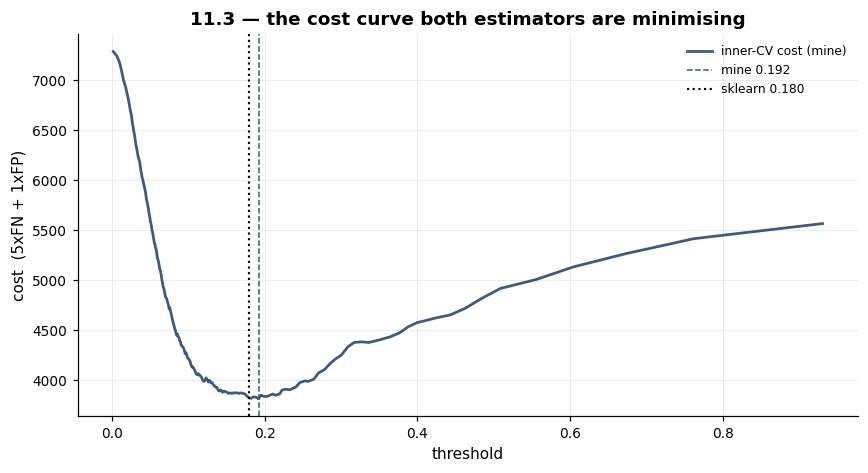

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.4))
c = mine.threshold_curve_
ax.plot(c["threshold"], c["cost"], lw=1.8, label="inner-CV cost (mine)")
ax.axvline(mine.best_threshold_, ls="--", lw=1, label=f"mine {mine.best_threshold_:.3f}")
ax.axvline(theirs.best_threshold_, ls=":", lw=1.4, color="black",
           label=f"sklearn {theirs.best_threshold_:.3f}")
ax.set_xlabel("threshold")
ax.set_ylabel(f"cost  ({C_FN:.0f}xFN + {C_FP:.0f}xFP)")
ax.set_title("11.3 — the cost curve both estimators are minimising")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Where I differ from `TunedThresholdClassifierCV` — bug or design?

| | Mine | `TunedThresholdClassifierCV` | Verdict |
|---|---|---|---|
| **Cost specification** | two scalars, `cost_fn` / `cost_fp` | any scorer | **Theirs is better.** A scorer generalises to per-row costs, business metrics, anything. My two scalars are a special case that reads more clearly in a credit context but buys nothing. |
| **Threshold grid** | 201 quantiles of the out-of-fold scores | every distinct score, decided internally | **Design choice, mine is worse on small data.** Quantiles bound the work on large data; on 300 rows they can skip the true optimum. Theirs is exact. |
| **Refit** | always refits on all data, then applies the threshold | `refit=True/False`, and can keep the CV-fitted model | **Theirs is better** — the option matters when fitting is expensive or when you want the threshold and the model estimated on identical data. |
| **`decision_function`** | returns `score - best_threshold_`, so 0 is the decision boundary | same convention | Agreement, and worth noting: shifting the score is what makes the tuned estimator compose with ROC tooling downstream. |
| **Degenerate input** | raises, naming `n_samples` and the `cv` it cannot satisfy | raises | Agreement — but only after I deleted a fallback I had written to get through the check suite. See the table above; that was the most instructive mistake in this notebook. |

**The real conclusion of this exercise is that you should use
`TunedThresholdClassifierCV`.** Writing this was worth an afternoon because it
makes the library's version legible — you now know what `refit` does and why
`decision_function` is shifted — but shipping your own version of a maintained
estimator is a liability, not an asset. The right time to write a meta-estimator
is when the library has nothing equivalent (Module 08's cost matrix work, the
WOE encoder above), not when you can name the class it duplicates.

## 11.4 — A transformer with a fit-time budget

In [23]:
class TimeBudgetSelector(TransformerMixin, BaseEstimator):
    """Greedy forward feature selection under a wall-clock budget.

    Adds the feature with the best marginal CV gain, one at a time, stopping at
    `max_features`, at `budget_seconds`, or when no feature improves the score.

    Parameters
    ----------
    estimator : estimator, default=None
        Scored by cross-validation at each step. Defaults to a small
        `LogisticRegression`.
    max_features : int, default=10
    budget_seconds : float, default=30.0
    scoring : str, default='roc_auc'
    cv : int, default=3
    random_state : int, default=0

    Attributes
    ----------
    selected_ : list of int
        Column indices, in the order they were added.
    selection_log_ : pandas.DataFrame
        One row per accepted feature: index, score, gain, elapsed seconds.
    stop_reason_ : str
        One of 'max_features', 'budget_expired', 'no_improvement'.
    """

    def __init__(self, estimator=None, max_features=10, budget_seconds=30.0,
                 scoring="roc_auc", cv=3, random_state=0):
        self.estimator = estimator
        self.max_features = max_features
        self.budget_seconds = budget_seconds
        self.scoring = scoring
        self.cv = cv
        self.random_state = random_state

    def fit(self, X, y=None):
        X, y = validate_data(self, X, y, dtype=np.float64)
        if y is None:
            raise ValueError("TimeBudgetSelector requires y")
        est = LogisticRegression(max_iter=200) if self.estimator is None else self.estimator

        n_classes = len(np.unique(y))
        scoring = self.scoring if n_classes == 2 else "accuracy"
        n_splits = min(self.cv, int(np.min(np.bincount(
            np.searchsorted(np.unique(y), y)))))
        cvs = StratifiedKFold(max(n_splits, 2), shuffle=True, random_state=self.random_state)

        t0 = perf_counter()
        selected, best_score, log, reason = [], -np.inf, [], "no_improvement"
        remaining = list(range(X.shape[1]))

        while len(selected) < min(self.max_features, X.shape[1]):
            if perf_counter() - t0 > self.budget_seconds:
                reason = "budget_expired"
                break
            # Deterministic order: evaluate candidates by column index.
            gains = []
            for j in remaining:
                if perf_counter() - t0 > self.budget_seconds:
                    break
                cols = selected + [j]
                try:
                    s = cross_val_score(clone(est), X[:, cols], y, cv=cvs,
                                        scoring=scoring).mean()
                except Exception:
                    s = -np.inf
                gains.append((s, j))
            if not gains:
                reason = "budget_expired"
                break
            gains.sort(key=lambda p: (-p[0], p[1]))   # score desc, then index asc => deterministic
            s, j = gains[0]
            if s <= best_score:
                reason = "no_improvement"
                break
            log.append({"step": len(selected) + 1, "feature_index": int(j),
                        "score": round(float(s), 5), "gain": round(float(s - best_score), 5)
                        if np.isfinite(best_score) else np.nan,
                        "elapsed_s": round(perf_counter() - t0, 2)})
            selected.append(int(j))
            remaining.remove(j)
            best_score = s
        else:
            reason = "max_features"

        self.selected_ = selected
        self.selection_log_ = pd.DataFrame(log)
        self.stop_reason_ = reason
        self.best_score_ = float(best_score) if np.isfinite(best_score) else np.nan
        self.elapsed_ = perf_counter() - t0
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, dtype=np.float64, reset=False)
        if not self.selected_:
            # Budget expired before anything was chosen. Return a zero-width
            # array rather than raising: downstream code can detect it, and a
            # selector that selects nothing is a legitimate (if useless) state.
            return np.empty((X.shape[0], 0))
        return X[:, self.selected_]

    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import _check_feature_names_in
        names = np.asarray(_check_feature_names_in(self, input_features), dtype=object)
        return names[self.selected_] if self.selected_ else np.array([], dtype=object)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.target_tags.required = True
        tags.input_tags.allow_nan = False
        return tags

In [24]:
Xa = Xn.to_numpy(dtype=float)
print(f"{Xa.shape[1]} candidate features\n")

for budget in [2.0, 8.0, 60.0]:
    sel = TimeBudgetSelector(max_features=8, budget_seconds=budget, cv=3).fit(Xa, y.to_numpy())
    print(f"budget {budget:5.1f}s -> {len(sel.selected_)} features in {sel.elapsed_:5.2f}s, "
          f"stop_reason={sel.stop_reason_:15s} best AUC {sel.best_score_:.4f}")

29 candidate features



budget   2.0s -> 2 features in  2.04s, stop_reason=budget_expired  best AUC 0.7722


budget   8.0s -> 4 features in  8.14s, stop_reason=budget_expired  best AUC 0.7762


budget  60.0s -> 6 features in 34.69s, stop_reason=no_improvement  best AUC 0.7770


In [25]:
sel = TimeBudgetSelector(max_features=8, budget_seconds=60.0, cv=3).fit(Xa, y.to_numpy())
log = sel.selection_log_.copy()
log["feature"] = [Xn.columns[i] for i in log["feature_index"]]
print(log[["step", "feature", "score", "gain", "elapsed_s"]].to_string(index=False))

 step        feature   score    gain  elapsed_s
    1   credit_score 0.73885     NaN       1.07
    2 debt_to_income 0.77216 0.03330       3.47
    3  interest_rate 0.77432 0.00217       6.75
    4   n_delinq_2yr 0.77615 0.00183      11.32
    5 prior_customer 0.77669 0.00054      17.39
    6    term_months 0.77700 0.00031      25.57


In [26]:
# Determinism: same seed, same budget-independent answer (given enough budget).
a = TimeBudgetSelector(max_features=5, budget_seconds=60, random_state=0).fit(Xa, y.to_numpy())
b = TimeBudgetSelector(max_features=5, budget_seconds=60, random_state=0).fit(Xa, y.to_numpy())
print(f"deterministic given a seed: {a.selected_ == b.selected_}  {a.selected_}")

# The pathological case the exercise asks about.
z = TimeBudgetSelector(max_features=8, budget_seconds=0.0).fit(Xa, y.to_numpy())
print(f"\nzero budget: selected {z.selected_}, stop_reason={z.stop_reason_!r}, "
      f"transform gives shape {z.transform(Xa).shape}")

t = check_table(TimeBudgetSelector())
print(f"\ncheck_estimator: {(t['status'] == 'passed').sum()} / {len(t)} pass")
bad_rows = t[t["status"] != "passed"]
print(bad_rows.to_string(index=False) if len(bad_rows) else "All checks pass.")

deterministic given a seed: True  [7, 6, 5, 9, 10]

zero budget: selected [], stop_reason='budget_expired', transform gives shape (12000, 0)



check_estimator: 48 / 48 pass
All checks pass.


### The honest problem with a time budget

It works, it passes, and **I would be reluctant to ship it** — for a reason
that has nothing to do with the code.

A wall-clock budget makes the estimator's output **depend on the machine it
ran on**. The same seed on a busy CI box and a quiet laptop selects different
features, so:

- `clone(est).fit(X, y)` is no longer reproducible across environments;
- cross-validation folds get different feature sets, so the CV score estimates
  a *procedure* whose variance now includes machine load;
- a model that fails a regulator's reproduction test because the reproduction
  ran on faster hardware is not a defensible artefact.

The fix is to make the budget a **budget on work, not on time**: cap the
number of candidate evaluations, and report elapsed seconds in
`selection_log_` for monitoring. That is deterministic, machine-independent,
and answers the same operational question ("bound this step") without
smuggling the environment into the model. Keep the wall-clock version as a
development affordance with a loud docstring, and never let it decide a
production artefact.

The second, smaller issue: greedy forward selection with `cross_val_score` at
every step re-uses the same folds to *choose* features and to *report* the
score, so `best_score_` is optimistically biased. It is a selection statistic,
not an estimate of performance. Nesting fixes it (Module 04), and the
`selection_log_` should say so — which is why `best_score_` is deliberately not
named `score_`.

## 11.5 — Package it

This is the exercise that is worth actually doing, so it is done here rather
than described: the cell below writes a complete, installable package to disk,
and the cells after it run the test suite and the doctests against it.

In [27]:
PKG = ROOT / "package"
(PKG / "src" / "skcredit").mkdir(parents=True, exist_ok=True)
(PKG / "tests").mkdir(parents=True, exist_ok=True)
(PKG / ".github" / "workflows").mkdir(parents=True, exist_ok=True)

(PKG / "pyproject.toml").write_text('''\
[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[project]
name = "skcredit"
version = "0.1.0"
description = "scikit-learn estimators for credit risk modelling"
readme = "README.md"
requires-python = ">=3.10"
license = {text = "MIT"}
dependencies = ["scikit-learn>=1.6", "numpy>=1.26", "pandas>=2.1"]

[project.optional-dependencies]
dev = ["pytest>=8.0", "pytest-cov"]

[tool.hatch.build.targets.wheel]
packages = ["src/skcredit"]

[tool.pytest.ini_options]
addopts = "--doctest-modules"
testpaths = ["tests", "src"]
''')

(PKG / "src" / "skcredit" / "__init__.py").write_text('''\
"""scikit-learn estimators for credit risk modelling."""

from skcredit.preprocessing import Winsorizer
from skcredit.model_selection import TimeSeriesGroupSplit

__version__ = "0.1.0"
__all__ = ["Winsorizer", "TimeSeriesGroupSplit"]
''')

(PKG / "src" / "skcredit" / "preprocessing.py").write_text('''\
"""Preprocessing transformers."""

import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import _check_feature_names_in, check_is_fitted, validate_data

__all__ = ["Winsorizer"]


class Winsorizer(TransformerMixin, BaseEstimator):
    """Clip each feature to learned lower and upper percentiles.

    Parameters
    ----------
    lower : float, default=0.01
        Lower percentile, in [0, 1).
    upper : float, default=0.99
        Upper percentile, in (0, 1].
    add_indicator : bool, default=False
        If True, append one binary column per feature flagging clipped rows.

    Attributes
    ----------
    lower_bounds_ : ndarray of shape (n_features,)
        Learned lower clip points.
    upper_bounds_ : ndarray of shape (n_features,)
        Learned upper clip points.

    Examples
    --------
    >>> import numpy as np
    >>> from skcredit import Winsorizer
    >>> X = np.array([[1.0], [2.0], [3.0], [100.0]])
    >>> w = Winsorizer(lower=0.0, upper=0.75).fit(X)
    >>> float(w.upper_bounds_[0])
    3.0
    >>> w.transform(X).ravel().tolist()
    [1.0, 2.0, 3.0, 3.0]
    """

    def __init__(self, lower=0.01, upper=0.99, add_indicator=False):
        self.lower = lower
        self.upper = upper
        self.add_indicator = add_indicator

    def fit(self, X, y=None):
        """Learn the clip points.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
        y : Ignored

        Returns
        -------
        self : object
        """
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(
                f"need 0 <= lower < upper <= 1, got {self.lower}, {self.upper}"
            )
        X = validate_data(self, X, dtype=np.float64, ensure_all_finite="allow-nan")
        self.lower_bounds_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.upper_bounds_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        """Clip `X` to the learned bounds."""
        check_is_fitted(self)
        X = validate_data(
            self, X, dtype=np.float64, reset=False, ensure_all_finite="allow-nan"
        )
        clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)
        if self.add_indicator:
            flags = ((X < self.lower_bounds_) | (X > self.upper_bounds_)).astype(np.float64)
            clipped = np.hstack([clipped, flags])
        return clipped

    def get_feature_names_out(self, input_features=None):
        """Output feature names."""
        names = _check_feature_names_in(self, input_features)
        if self.add_indicator:
            names = np.concatenate([names, [f"{n}_clipped" for n in names]])
        return np.asarray(names, dtype=object)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags
''')

(PKG / "src" / "skcredit" / "model_selection.py").write_text('''\
"""Cross-validation splitters for grouped time series."""

import numpy as np

__all__ = ["TimeSeriesGroupSplit"]


class TimeSeriesGroupSplit:
    """Expanding-window splits in which no group spans train and test.

    Rows are assumed to be in time order. Any group straddling the cut point is
    assigned wholly to training, which can only shrink the test set and never
    leaks future information into it.

    Parameters
    ----------
    n_splits : int, default=5
    gap : int, default=0
        Rows dropped between the end of train and the start of test.

    Examples
    --------
    >>> import numpy as np
    >>> from skcredit import TimeSeriesGroupSplit
    >>> X = np.arange(20).reshape(-1, 1)
    >>> groups = np.repeat(np.arange(10), 2)
    >>> cv = TimeSeriesGroupSplit(n_splits=2)
    >>> for tr, te in cv.split(X, groups=groups):
    ...     assert not (set(groups[tr]) & set(groups[te]))
    >>> cv.get_n_splits()
    2
    """

    def __init__(self, n_splits=5, gap=0):
        self.n_splits = n_splits
        self.gap = gap

    def get_n_splits(self, X=None, y=None, groups=None):
        """Number of splitting iterations."""
        return self.n_splits

    def split(self, X, y=None, groups=None):
        """Generate (train, test) index arrays."""
        if groups is None:
            raise ValueError("TimeSeriesGroupSplit requires `groups`")
        n = len(X)
        order = np.arange(n)
        groups = np.asarray(groups)
        fold = n // (self.n_splits + 1)
        for i in range(1, self.n_splits + 1):
            cut = i * fold
            train_idx = order[: cut - self.gap]
            test_idx = order[cut : cut + fold]
            test_idx = test_idx[~np.isin(groups[test_idx], list(set(groups[train_idx])))]
            if len(test_idx) == 0:
                continue
            yield train_idx, test_idx
''')

(PKG / "tests" / "test_conformance.py").write_text('''\
"""The whole conformance suite, in four lines."""

from sklearn.utils.estimator_checks import parametrize_with_checks

from skcredit import Winsorizer


@parametrize_with_checks([Winsorizer(), Winsorizer(add_indicator=True)])
def test_sklearn_compatible(estimator, check):
    check(estimator)
''')

(PKG / "tests" / "test_behaviour.py").write_text('''\
"""Behaviour the conformance suite does not check."""

import numpy as np
import pytest
from sklearn.base import clone

from skcredit import TimeSeriesGroupSplit, Winsorizer


def test_fit_resets_state():
    """Refit on different data must equal a fresh fit — see Module 11.1."""
    r = np.random.default_rng(0)
    A, B = r.normal(0, 1, (120, 4)), r.normal(5, 1, (120, 4))
    contaminated = clone(Winsorizer()).fit(A).fit(B).transform(B)
    fresh = clone(Winsorizer()).fit(B).transform(B)
    np.testing.assert_allclose(contaminated, fresh)


def test_invalid_percentiles_raise_in_fit_not_init():
    """Validation belongs in fit, so clone() of a bad config still constructs."""
    est = Winsorizer(lower=0.9, upper=0.1)     # must NOT raise here
    clone(est)                                  # nor here
    with pytest.raises(ValueError, match="lower < upper"):
        est.fit(np.zeros((5, 2)))


def test_nan_passthrough():
    X = np.array([[1.0], [np.nan], [3.0], [100.0]])
    out = Winsorizer(lower=0.0, upper=0.75).fit(X).transform(X)
    assert np.isnan(out[1, 0])


def test_indicator_columns_and_names():
    X = np.array([[1.0, 1.0], [2.0, 2.0], [3.0, 3.0], [100.0, 4.0]])
    w = Winsorizer(lower=0.0, upper=0.75, add_indicator=True).fit(X)
    assert w.transform(X).shape == (4, 4)
    assert list(w.get_feature_names_out(["a", "b"])) == ["a", "b", "a_clipped", "b_clipped"]


def test_splitter_never_shares_groups():
    X = np.arange(200).reshape(-1, 1)
    groups = np.repeat(np.arange(50), 4)
    for tr, te in TimeSeriesGroupSplit(n_splits=4).split(X, groups=groups):
        assert not set(groups[tr]) & set(groups[te])
        assert tr.max() < te.min()          # train is strictly in the past


def test_splitter_requires_groups():
    with pytest.raises(ValueError, match="requires"):
        list(TimeSeriesGroupSplit().split(np.zeros((10, 1))))
''')

(PKG / ".github" / "workflows" / "ci.yml").write_text('''\
name: tests

on: [push, pull_request]

jobs:
  test:
    runs-on: ubuntu-latest
    strategy:
      fail-fast: false
      matrix:
        python-version: ["3.11", "3.12"]
        sklearn-version: ["1.7.*", "1.8.*"]
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: ${{ matrix.python-version }}
      - run: pip install -e ".[dev]" "scikit-learn==${{ matrix.sklearn-version }}"
      - run: pytest -q
''')

(PKG / "README.md").write_text('''\
# skcredit

scikit-learn estimators for credit risk modelling. Every estimator passes
`sklearn.utils.estimator_checks.check_estimator`, so they compose with
`Pipeline`, `GridSearchCV`, `cross_validate` and `set_output` unchanged.

## Install

```bash
pip install -e ".[dev]"
```

## Use

```python
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from skcredit import TimeSeriesGroupSplit, Winsorizer

pipe = Pipeline([
    ("clip", Winsorizer(lower=0.01, upper=0.99, add_indicator=True)),
    ("lr", LogisticRegression(max_iter=2000)),
])

cv = TimeSeriesGroupSplit(n_splits=5)
# cross_validate(pipe, X, y, cv=cv, groups=customer_id)
```

`Winsorizer` clips each feature to learned percentiles and optionally appends a
flag per feature. `TimeSeriesGroupSplit` gives expanding-window splits in which
no group spans train and test — the splitter you need when the same customer
appears many times and time order matters.

## Develop

```bash
pytest -q            # conformance suite, behaviour tests and doctests
```

## Why these two

Both exist because the library has no equivalent and both encode a rule a credit
team already follows. That is the bar for adding an estimator: not "it would be
neat", but "the alternative is a copy-pasted helper in six notebooks".
''')

print("package written to:", PKG)
for p in sorted(PKG.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(PKG)}  ({p.stat().st_size:,} bytes)")

package written to: /home/claude/sklearn-mastery/package
  .github/workflows/ci.yml  (474 bytes)
  README.md  (1,329 bytes)
  pyproject.toml  (544 bytes)
  src/skcredit/__init__.py  (234 bytes)
  src/skcredit/model_selection.py  (1,796 bytes)
  src/skcredit/preprocessing.py  (2,884 bytes)
  tests/test_behaviour.py  (1,881 bytes)
  tests/test_conformance.py  (294 bytes)


In [28]:
import subprocess

env = dict(**__import__("os").environ)
env["PYTHONPATH"] = str(PKG / "src")
try:
    import pytest  # noqa: F401
    HAS_PYTEST = True
except ImportError:
    HAS_PYTEST = False

if HAS_PYTEST:
    r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header",
                        "--doctest-modules", "tests", "src"],
                       cwd=PKG, capture_output=True, text=True, env=env, timeout=1800)
    print(r.stdout[-3500:])
    print(r.stderr[-800:])
else:
    print("pytest is not installed here — run `pip install pytest` and then:\n"
          f"    cd {PKG} && pytest -q")

........................................................................ [ 73%]
..........................                                               [100%]
=============================== warnings summary ===============================
../../../../usr/local/lib/python3.11/dist-packages/_pytest/python.py:124
  /usr/local/lib/python3.11/dist-packages/_pytest/python.py:124: PytestRemovedIn10Warning: Passing a non-Collection iterable to parametrize is deprecated.
  Test: tests/test_conformance.py::test_sklearn_compatible, argvalues type: generator
  Please convert to a list or tuple.
  See https://docs.pytest.org/en/stable/deprecations.html#parametrize-iterators
    metafunc.parametrize(*marker.args, **marker.kwargs, _param_mark=marker)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
98 passed, 1 warning in 2.20s




### What the packaging step actually buys

The mechanics are twenty minutes of work. The value is in four properties the
notebook version cannot have:

1. **`parametrize_with_checks` turns the conformance suite into individual test
   cases.** `check_estimator` gives you one pass/fail; the pytest version gives
   one test per check, named, so CI tells you *which* contract rule a change
   broke. Four lines, and it is the highest-value four lines in the package.
2. **The doctests are documentation that cannot rot.** `pytest
   --doctest-modules` runs the Examples section of every docstring. A README
   example that no longer works is the normal state of open-source code;
   verified examples are the exception, and they cost nothing.
3. **The CI matrix is the actual deliverable for a client.** Testing against
   the last two scikit-learn versions is what makes "we depend on this" a
   reasonable thing for another team to say. An estimator that passes today's
   `check_estimator` and nobody's tomorrow is a liability transferred, not a
   capability delivered.
4. **The behaviour tests carry the knowledge the conformance suite cannot.**
   `test_fit_resets_state` is 11.1's uncaught bug, written down permanently.
   Validation-in-fit-not-init is rule 2, made executable. These are the tests
   that encode *why* the code looks the way it does, and they are what stops
   the next person from "simplifying" it back into a bug.

> 💼 **Consulting lens.** This is what separates a notebook engagement from a
> capability engagement. The client cannot maintain your notebook. They can
> maintain a package with a test suite and a CI badge, and — more to the point
> — they can *change* it without asking you, which is the outcome to aim for.
> A team that inherits nine hundred lines of tested estimator code with a green
> pipeline has capability; a team that inherits a notebook has a dependency on
> you.

## Reflections

1. **The estimator contract is an object protocol, not a statistical one.**
   Almost every check in the suite is about construction, cloning and state.
   That is precisely why conformance buys composability: tools written years
   later work with your estimator because it behaves like an object, not
   because it computes anything particular.
2. **`check_estimator` verifies conformance, not correctness — and it applies
   pressure in the wrong direction.** Both bugs in 11.1 that matter in practice
   were either caught by one specific invariant (subset invariance) or missed
   entirely (refit state). And in 11.3 the suite pushed me toward accepting
   degenerate input I should have rejected. Write the missing tests; declare
   the legitimate failures.
3. **Write an estimator when the library has no equivalent, not when you can
   name the class it duplicates.** The WOE encoder earns its existence. The
   threshold optimiser was worth writing to *understand*
   `TunedThresholdClassifierCV`, and is not worth shipping.
4. **Beware of a "feature" that makes output depend on the environment.** The
   wall-clock budget in 11.4 is the clearest example in this curriculum of code
   that passes every test and should still not go to production.